In [46]:
!pip install pyabf
import pyabf
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import find_peaks
from scipy import signal

# Lab 6: Más allá del disparo tónico

## Ejercicio 1

Una de las características interesantes de algunas céulas es la capacidad de generar los llamados *bursts* de actividad. Una secuencia rápida de trenes de spikes, seguido de un periodo sin actividad. A continuación su colega biólogo le presenta un experimento que ha hecho en el que ha encontrado bursting en una neurona marca pasos.

Este le pide que le ayude a hacer el análisis de sus datos.

1. Cargue los datos y grafique el potencial del membrana de la neurona registrada en este experimento

In [ ]:
abf = pyabf.ABF('/content/STG_PD_Bursts.abf')
t = abf.sweepX
v = abf.sweepY
c = abf.sweepC

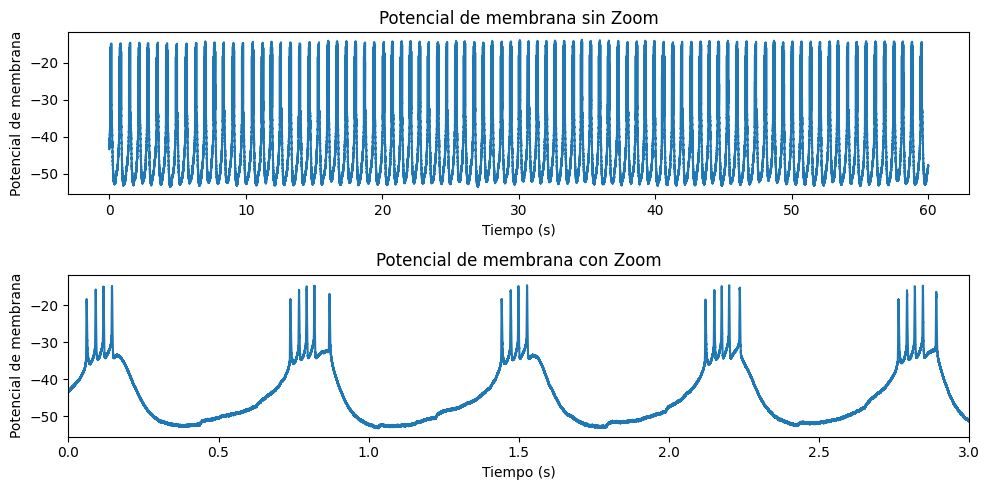

In [ ]:
plt.figure(figsize=(10,5))

plt.subplot(2,1,1)
plt.plot(t, v)
plt.xlabel('Tiempo (s)')
plt.ylabel('Potencial de membrana')
plt.title('Potencial de membrana sin Zoom')

plt.subplot(2,1,2)
plt.plot(t, v)
plt.xlabel('Tiempo (s)')
plt.ylabel('Potencial de membrana')
plt.xlim(0,3)
plt.title('Potencial de membrana con Zoom')
plt.tight_layout()
plt.show()

2. Identifique los spikes y grafíquelos encima de la gráfica anterior. Dado que la señal puede poseer ruido que haga aparecer pico espurios, verifique cómo el argumento *prominence* y *distance* de la función find_peaks puede ayudarle

In [ ]:
# Calculo de distance:
t[0], t[80] # 4 ms.

(0.0, 0.004)

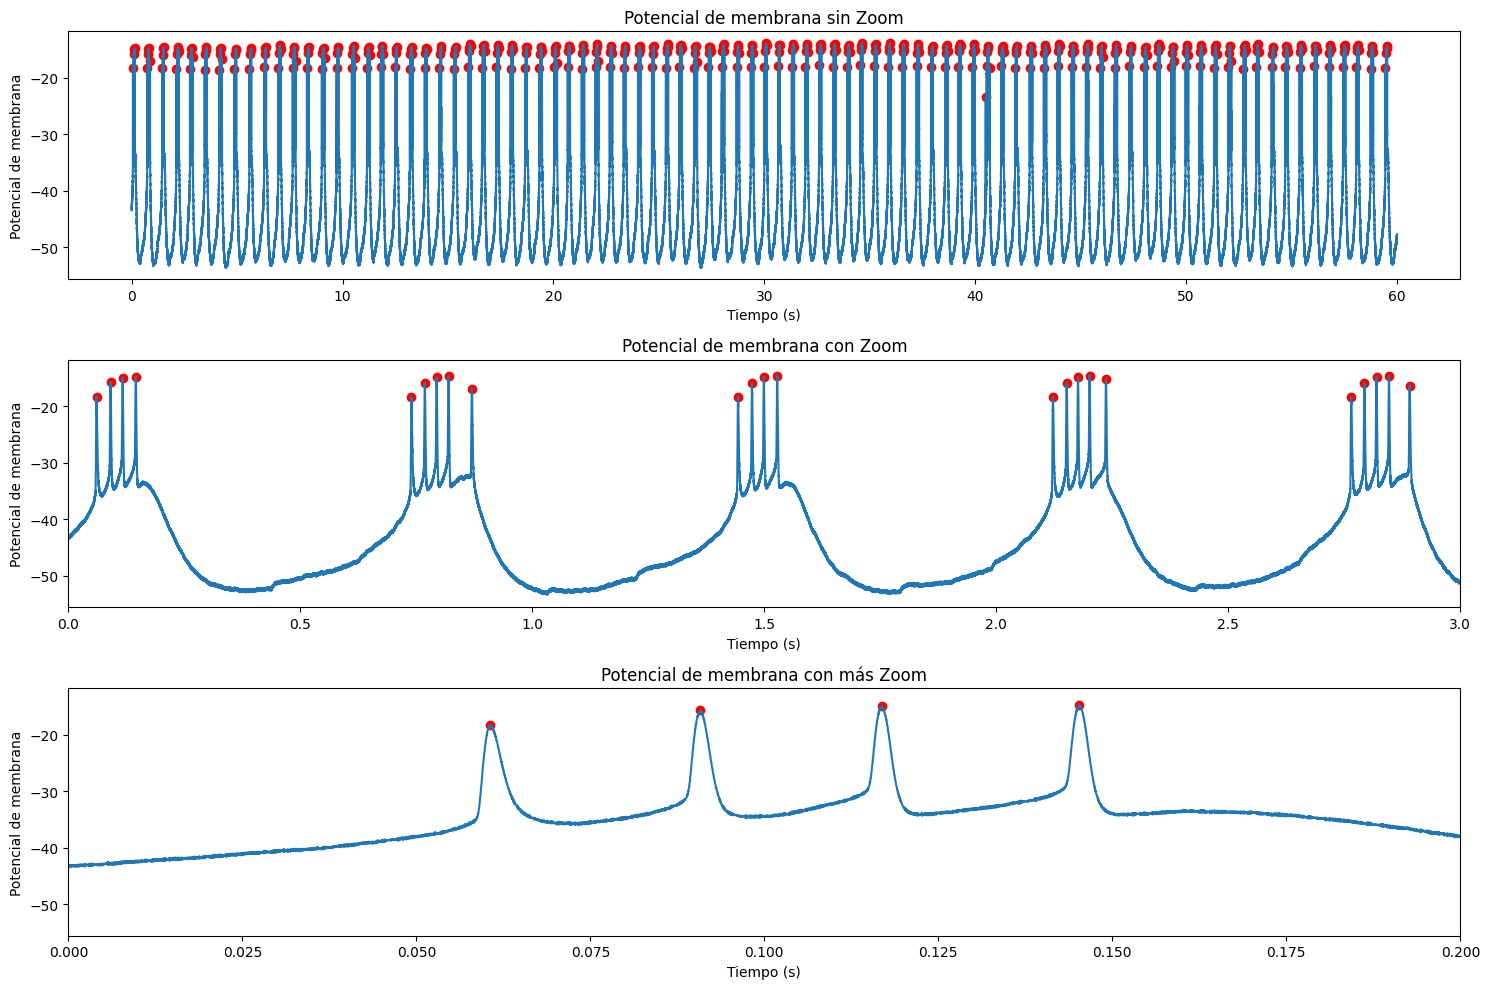

In [ ]:
# Encontrar picos pero solo mayores que 0 (es decir, que si sean spikes):
peakID,_ = find_peaks(v, distance = 80, prominence = 10)

# Evaluar los tiempos y los voltajes
tiempos_spikes = t[peakID]
valores_spikes = v[peakID]

plt.figure(figsize=(15,10))

plt.subplot(3,1,1)
plt.plot(t, v)
plt.scatter(tiempos_spikes, valores_spikes, color='red')
plt.xlabel('Tiempo (s)')
plt.ylabel('Potencial de membrana')
plt.title('Potencial de membrana sin Zoom')

plt.subplot(3,1,2)
plt.plot(t, v)
plt.xlabel('Tiempo (s)')
plt.ylabel('Potencial de membrana')
plt.scatter(tiempos_spikes, valores_spikes, color='red')
plt.xlim(0,3)
plt.title('Potencial de membrana con Zoom')

plt.subplot(3,1,3)
plt.plot(t, v)
plt.xlabel('Tiempo (s)')
plt.ylabel('Potencial de membrana')
plt.scatter(tiempos_spikes, valores_spikes, color='red')
plt.xlim(0,0.2)
plt.title('Potencial de membrana con más Zoom')

plt.tight_layout()
plt.show()
plt.show()

3. Haga el siguiente análisis de la señal:
    - Calcule el histograma del ISI.
    - Cuál es la frecuencia de disparo intra-burst?
    - Cuál es el tiempo promedio inter-burst?
    - Calcule el Coeficiente de Variación del ISI. $CV(ISI) = \frac{\sigma(ISI)}{\langle ISI \rangle}$

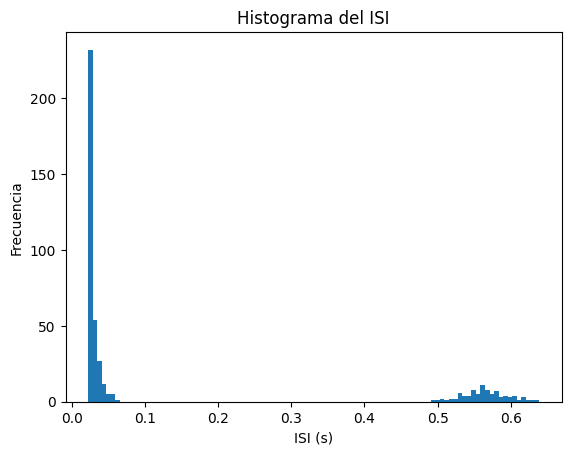

In [ ]:
# Calculo del ISI
ISI = np.diff(tiempos_spikes)

plt.hist(ISI, bins = 100)
plt.xlabel('ISI (s)')
plt.ylabel('Frecuencia')
plt.title('Histograma del ISI')
plt.show()

In [ ]:
ISI_intra=ISI[ISI < 0.1]
ISI_intra_mean = np.mean(ISI_intra)
Frec_disp_intra = 1/ISI_intra_mean
print(Frec_disp_intra)

34.23349074625946


In [ ]:
ISI_inter=ISI[ISI > 0.4]
ISI_inter_mean = np.mean(ISI_inter)
print(ISI_inter_mean)

0.564250568181818


In [ ]:
media_ISI = np.mean(ISI)
desv_ISI = np.std(ISI)
CV_ISI = desv_ISI/media_ISI
print(CV_ISI)

1.5507197414988112


4. Extraiga el tren de spikes dividiendo el tiempo del experimento en intervalos de tiempo $\Delta t = 20$ms y poniendo un 1 en los intervalos donde hay spikes y 0 donde no los hay y calcule
    - La función de autocorrelación del tren de spikes
    - Le densidad de potencia espectral

In [ ]:
# Partir el tiempo: (0.008 s)
Del_t = 0.008
values = np.arange(0, 60+Del_t, Del_t)
indices = np.searchsorted(t, values)
t_particion = []
for ind in range(len(indices)-1):
    i = indices[ind]
    j = indices[ind+1]
    t_particion.append(np.array(t[i:j]))
t_particion = np.array(t_particion)

In [ ]:
# Spikes en cada intervalo de la partición:
spikes = np.zeros(len(t_particion))
for i in range(len(t_particion)):
  spikes[i] = len(np.intersect1d(t_particion[i],tiempos_spikes))

In [ ]:
# Calcular la autocorrelación:
from scipy import signal

autocorrelacion = signal.correlate(spikes,spikes)

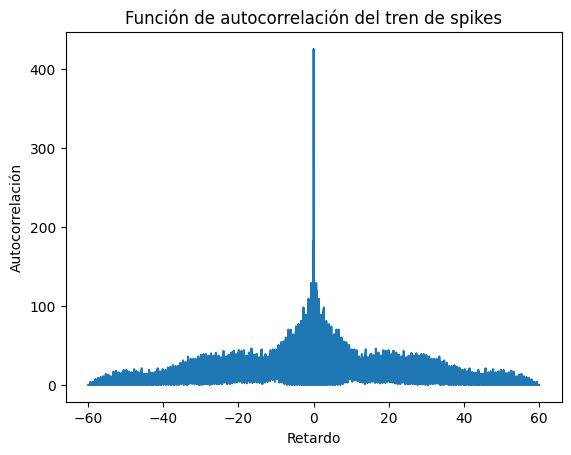

In [ ]:
# Doblo el tiempo para graficar completa:
eje_x = np.concatenate((-np.array(list(reversed(values[1:-1]))),np.array(values[:-1])))

plt.plot(eje_x,autocorrelacion)
plt.xlabel('Retardo')
plt.ylabel('Autocorrelación')
plt.title('Función de autocorrelación del tren de spikes')
plt.show()

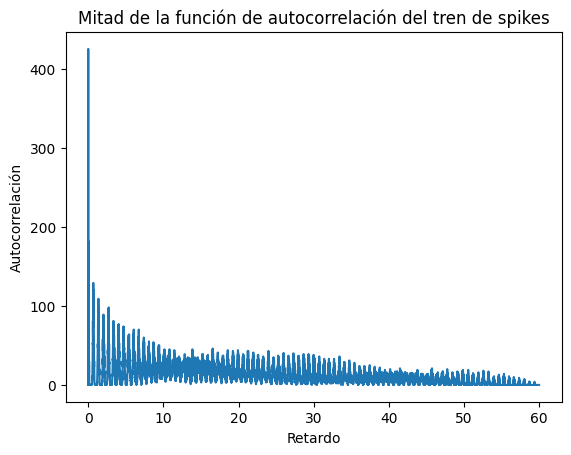

In [ ]:
# Divido la correlación para graficar solo la mitad.
plt.plot(values,autocorrelacion[len(spikes)-2:])
plt.xlabel('Retardo')
plt.ylabel('Autocorrelación')
plt.title('Mitad de la función de autocorrelación del tren de spikes')
plt.show()

- La densidad de potencia espectral.

Text(0, 0.5, 'Potencia')

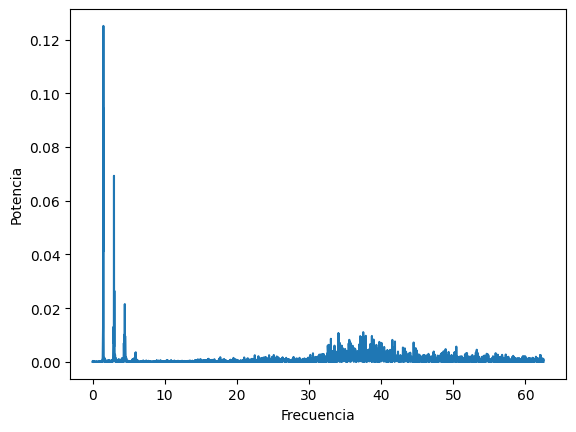

In [ ]:
from scipy import signal

frecuencia, potencia= signal.periodogram(spikes,fs = 1/Del_t)
plt.plot(frecuencia,potencia)
plt.xlabel('Frecuencia')
plt.ylabel('Potencia')

## Ejercicio 2

La siguiente tabla muestra los parámetros usados en el modelo AdEx para obtener diferentes patrones de disparo. Implemente los diferentes casos mostrando para cada uno la serie de tiempo del potencial de membrana así como el histograma del ISI, la función de autocorrelación del spike train y la densidad de potencia espectral.

Para todos los casos $\Delta_{T} = 2$, $V_{rh} = -50$.

- Adaptación: $\tau_m = 16.66$, $a = 2$, $b = 60$, $\tau_w = 300$, $R = 1/12$, $V_{rest} = -70$, $V_{reset} = -58$, $I=500$

- Bursting Regular: $\tau_m = 20$, $a = 2$, $b = 100$, $\tau_w = 120$, $R = 1/10$, $V_{rest} = -58$, $V_{reset} = -46$, $I=210$

- Burst Inicial: $\tau_m = 7.22$, $a = 4$, $b = 120$, $\tau_w = 150$, $R = 1/18$, $V_{rest} = -58$, $V_{reset} = -50$, $I=400$

- Irregular: $\tau_m = 8.33$, $a = -11$, $b = 30$, $\tau_w = 130$, $R = 1/12$, $V_{rest} = -60$, $V_{reset} = -48$, $I=160$

In [47]:
def simulacion(delta_T, Vrh, Vth, dt, t_fin, tau_m, a, b, tau_w, R, Vrest, Vreset, I, titulo):
  # Calcular cuantas iteraciones necesito:
  pasos = int(t_fin/dt)
  # Iicializar los arrays.
  t = np.arange(0, t_fin, dt)
  V = np.zeros(pasos)
  w = np.zeros(pasos)
  V_spike = np.array([])
  t_spike = np.array([])

  # Condiciones iniciales.
  V[0] = Vrest
  w[0] = 0

  # Iteración para estimar:
  for i in range(1, pasos):
    # Ecuaciones diferenciales
    dV = (-(V[i-1] - Vrest) + (delta_T * np.exp((V[i-1] - Vrh)/delta_T)) - R*w[i-1] + R*I)/tau_m
    dw = (a*(V[i-1] - Vrest) - w[i-1])/tau_w

    # Método de euler.
    V[i] = V[i-1] + dV*dt
    w[i] = w[i-1] + dw*dt

    # Detección de spikes
    if V[i] >= Vth:
      # Registrar el spike
      V_spike = np.append(V_spike, V[i-1])
      t_spike = np.append(t_spike, t[i-1])

      # Reorganización de las variables
      V[i] = Vreset
      w[i] += b


  plt.figure(figsize=(10, 5))
  plt.suptitle(f"AdEx - {titulo}")

  # Graficar el potencial de membrana:
  plt.subplot(2, 2, 1)
  plt.plot(t,V)
  plt.scatter(t_spike, V_spike, color='red')
  plt.xlabel('Tiempo (ms)')
  plt.ylabel('Potencial (mV)')
  plt.title('Potencial de membrana')


  # Graficar el ISI.
  # Calculo del ISI
  ISI = np.diff(t_spike)

  plt.subplot(2, 2, 2)
  plt.hist(ISI, bins = 50)
  plt.xlabel('ISI (s)')
  plt.ylabel('Frecuencia')
  plt.title('Histograma del ISI')

  # Graficar la función de autocorrelación del tren de spike.
  # Partir el tiempo: (0.008 s)
  values = np.arange(0, 1000+dt, dt)
  indices = np.searchsorted(t, values)
  t_particion = []
  for ind in range(len(indices)-1):
      i = indices[ind]
      j = indices[ind+1]
      t_particion.append(np.array(t[i:j]))
  t_particion = np.array(t_particion)

  # Spikes en cada intervalo de la partición:
  spikes = np.zeros(len(t_particion))
  for i in range(len(t_particion)):
    spikes[i] = len(np.intersect1d(t_particion[i],t_spike))

  # Calcular la autocorrelación del tren de spike:
  autocorrelacion = signal.correlate(spikes,spikes)

  # Divido la correlación para graficar solo la mitad.
  # Doblo el tiempo para graficar completa:
  eje_x = np.concatenate((-np.array(list(reversed(values[1:-1]))),np.array(values[:-1])))
  plt.subplot(2, 2, 3)
  plt.plot(eje_x,autocorrelacion)
  plt.xlabel('Retardo')
  plt.ylabel('Autocorrelación')
  plt.title('Función de autocorrelación del tren de spikes')

  # Graficar la frecuencia espectral.
  plt.subplot(2, 2, 4)
  frecuencia, potencia= signal.periodogram(spikes,fs = 1/dt)
  plt.plot(frecuencia,potencia)
  plt.xlabel('Frecuencia')
  plt.ylabel('Potencia')
  plt.title('Frecuencia espectral')

  plt.tight_layout()
  plt.show()
# Parámetros fijos:
delta_T = 2
Vrh = -50
Vth = -30
dt = delta_T
t_fin = 1000

### Adaptación:

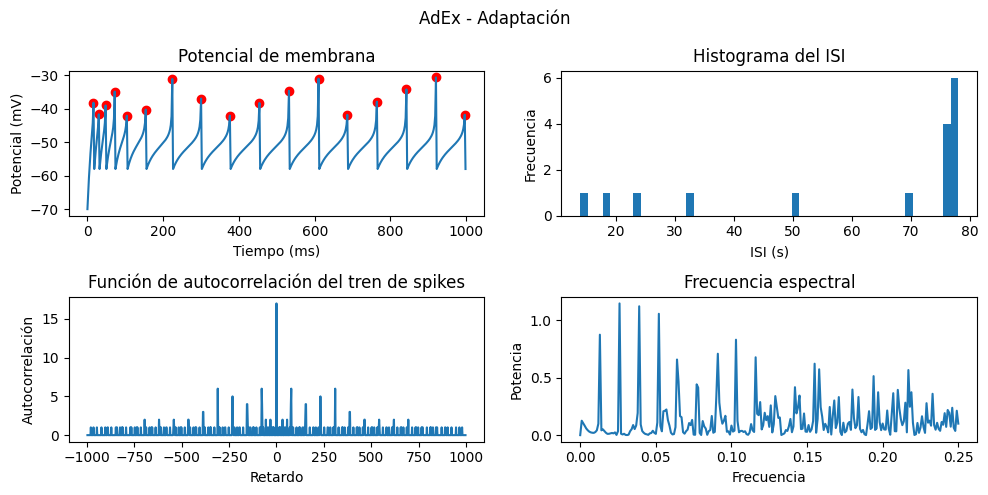

In [48]:
# Parámtros adaptacion:
tau_m = 16.66
a = 2
b = 60
tau_w = 300
R = 1/12
Vrest = -70
Vreset = -58
I = 500

simulacion(delta_T, Vrh, Vth, dt, t_fin, tau_m, a, b, tau_w, R, Vrest, Vreset, I, "Adaptación")

### Bursting regular:

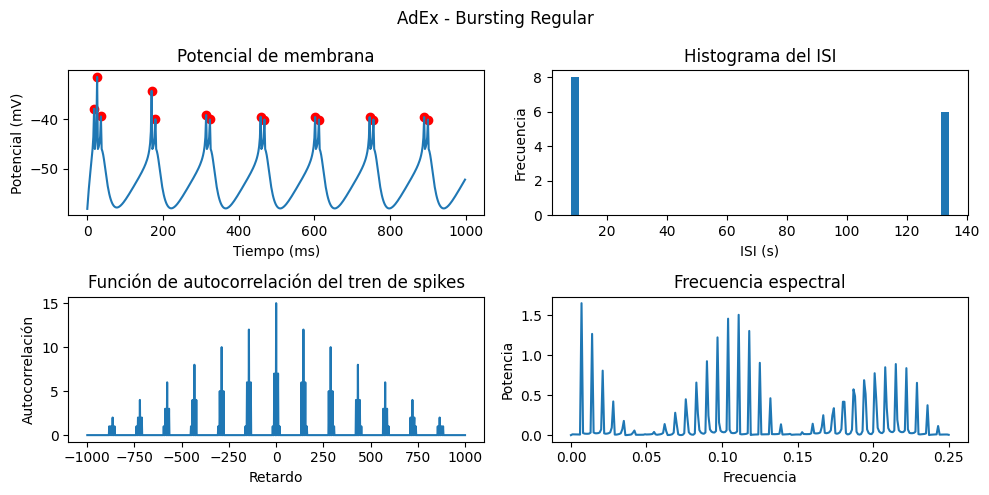

In [49]:
# Parámetros Bursting Regular
tau_m = 20
a = 2
b = 100
tau_w = 120
R = 1/10
Vrest = -58
Vreset = -46
I = 210

simulacion(delta_T, Vrh, Vth, dt, t_fin, tau_m, a, b, tau_w, R, Vrest, Vreset, I, "Bursting Regular")

### Bursting inicial:

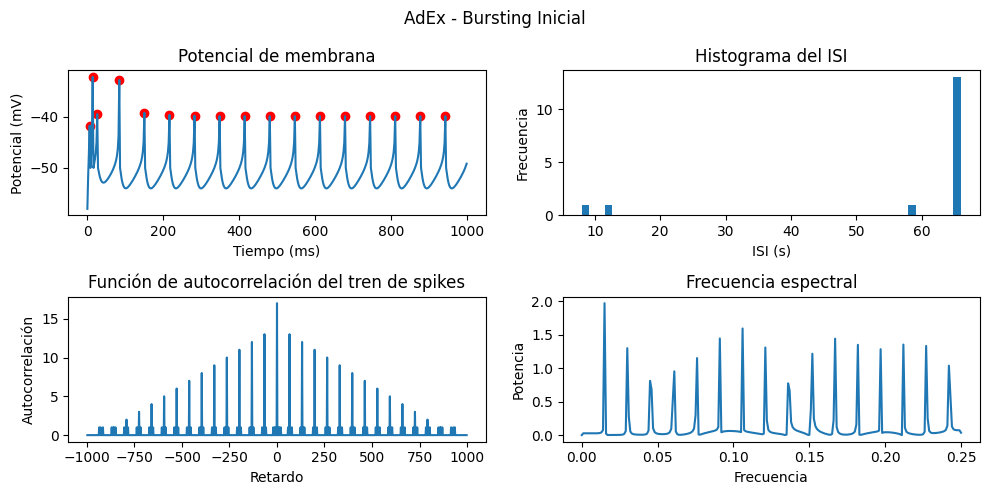

In [50]:
# Bursting inicial.
tau_m = 7.22
a = 4
b = 120
tau_w = 150
R = 1/18
Vrest = -58
Vreset = -50
I = 400

simulacion(delta_T, Vrh, Vth, dt, t_fin, tau_m, a, b, tau_w, R, Vrest, Vreset, I, "Bursting Inicial")

### Irregular

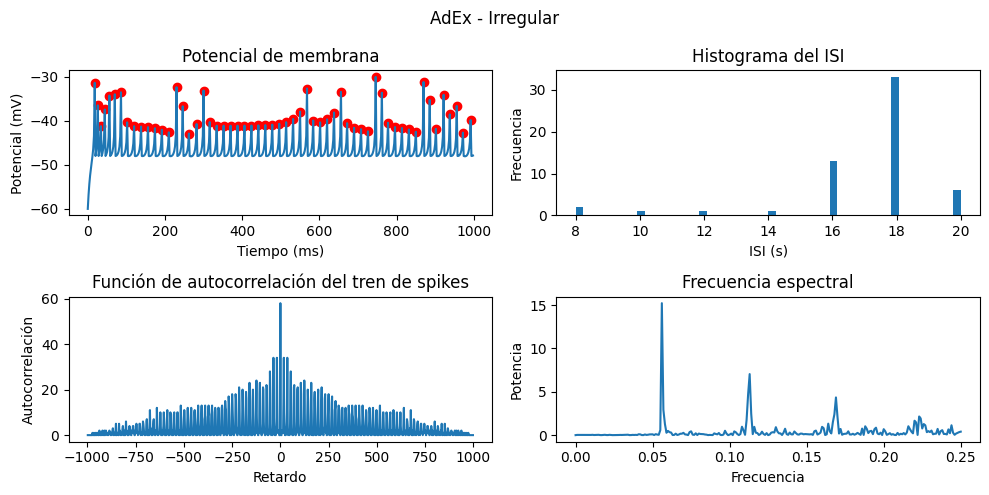

In [51]:
# Irregular.
tau_m = 8.33
a = -11
b = 30
tau_w = 130
R = 1/12
Vrest = -60
Vreset = -48
I = 160

simulacion(delta_T, Vrh, Vth, dt, t_fin, tau_m, a, b, tau_w, R, Vrest, Vreset, I, "Irregular")